In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Fish.csv")

In [3]:
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [5]:
df.shape

(159, 7)

In [7]:
df.isna().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

<Axes: >

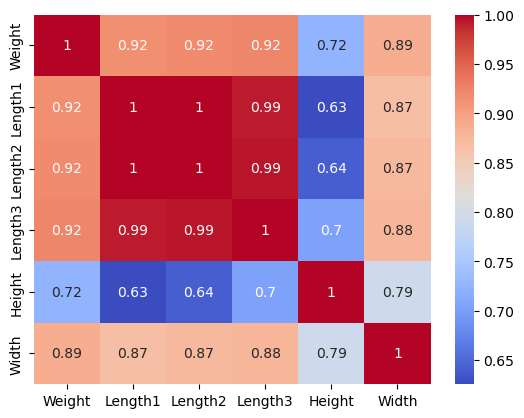

In [10]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

<Axes: xlabel='Length1', ylabel='Weight'>

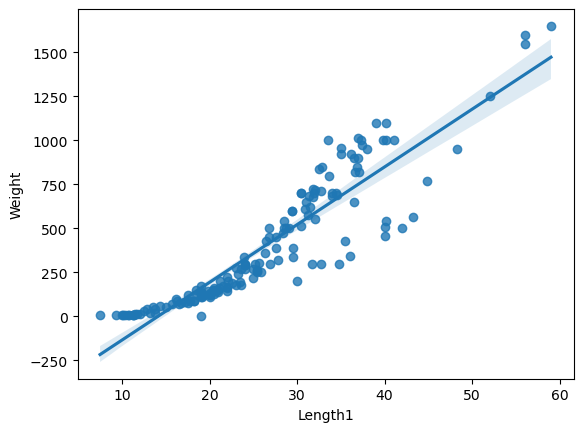

In [11]:
sns.regplot(data=df,x="Length1",y="Weight")

In [12]:
x=df[["Length1"]]#2d data only should be there
y=df[["Weight"]]

In [13]:
x,y

(     Length1
 0       23.2
 1       24.0
 2       23.9
 3       26.3
 4       26.5
 ..       ...
 154     11.5
 155     11.7
 156     12.1
 157     13.2
 158     13.8
 
 [159 rows x 1 columns],
      Weight
 0     242.0
 1     290.0
 2     340.0
 3     363.0
 4     430.0
 ..      ...
 154    12.2
 155    13.4
 156    12.2
 157    19.7
 158    19.9
 
 [159 rows x 1 columns])

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [18]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(127, 1)
(32, 1)
(127, 1)
(32, 1)


In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
model=LinearRegression()

In [21]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
model.coef_

array([[32.44308998]])

In [23]:
model.intercept_

array([-464.13411601])

In [24]:
15*32.44308998+(-464.13411601)

22.512233690000016

In [25]:
y_pred=model.predict(X_test)

In [26]:
y_pred

array([[  80.9097957 ],
       [ -84.54996321],
       [ 509.15858348],
       [ 301.52280759],
       [ 217.17077363],
       [ 622.70939842],
       [-136.45890718],
       [ 301.52280759],
       [ 269.07971761],
       [1222.9065631 ],
       [ 541.60167346],
       [ 745.99314035],
       [ 489.69272949],
       [ 132.81873968],
       [ 570.80045445],
       [ 671.37403339],
       [ 840.0781013 ],
       [ 346.94313356],
       [ 249.61386362],
       [ 522.13581947],
       [ -97.5271992 ],
       [ 538.35736446],
       [ 479.95980249],
       [ 460.4939485 ],
       [ 671.37403339],
       [ 836.83379231],
       [ 233.39231862],
       [ 317.74435258],
       [-162.41337917],
       [ -97.5271992 ],
       [ 833.58948331],
       [  45.22239672]])

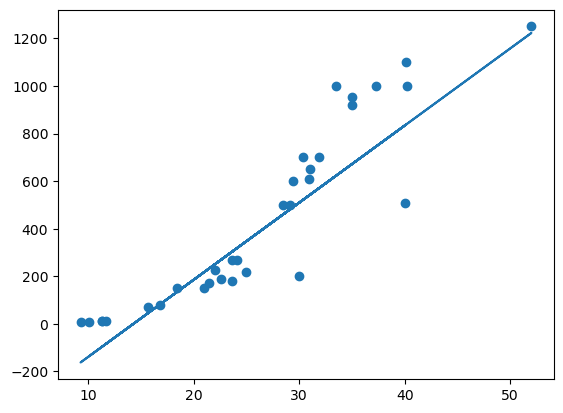

In [27]:
plt.plot(X_test,y_pred)
plt.scatter(X_test,y_test)
plt.show()

In [28]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [29]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

129.36788419512138
26796.684740821387
0.8116084146869396


In [33]:
pred=model.predict(np.array([[25]]))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [34]:
pred

array([[346.94313356]])

In [35]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [39]:
dd=pd.read_csv("Fish.csv")

In [41]:
x=dd.drop(["Species","Weight"],axis=1)
y=dd[["Weight"]]
X_train, X_test, y_train, y_test = train_test_split(
     x, y, test_size=0.2, random_state=40)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(mean_absolute_error(y_test,y_pred))

print(mean_squared_error(y_test,y_pred))

print(r2_score(y_test,y_pred))

109.0632714203943
21303.013279012113
0.8679594534557271


In [ ]:
# plotting mse,r2_score for test size=[0.75,0.8,0.85,0.9,0.95]

In [52]:
x=dd.drop(["Species","Weight"],axis=1)
y=dd[["Weight"]]
test=[0.75,0.8,0.85,0.9,0.95]
mse=[]
r2=[]
for i in test:
        X_train, X_test, y_train, y_test = train_test_split(
             x, y, test_size=i, random_state=40)
        model=LinearRegression()
        model.fit(X_train,y_train)
        y_pred=model.predict(X_test)
    
    
        mse.append(mean_squared_error(y_test,y_pred))
    
        r2.append(r2_score(y_test,y_pred))
        print(model.predict(np.array([[10,10,10,10,10]])))

[[625.82515147]]
[[502.4333856]]
[[935.26653348]]
[[74.46155573]]
[[629.13953432]]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


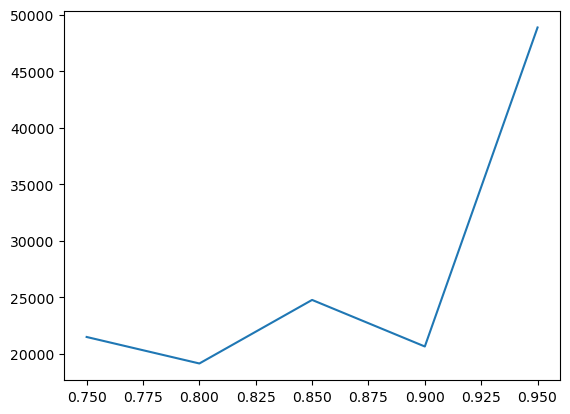

In [50]:
plt.plot(test,mse)

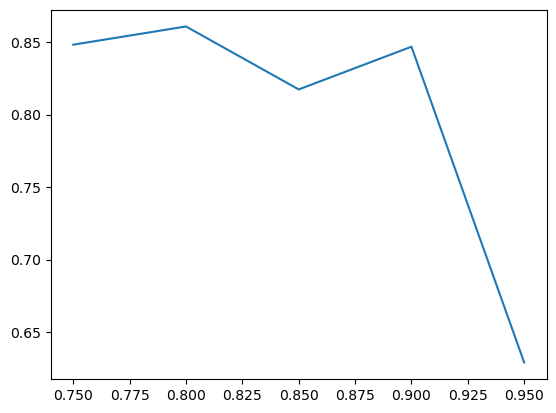

In [51]:
plt.plot(test,r2)

In [53]:
dd

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [54]:
df1=pd.read_csv("Ice_cream selling data.csv")

In [55]:
df1

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
x=df1[["Temperature (°C)"]]
y=df1[["Ice Cream Sales (units)"]]
X_train, X_test, y_train, y_test = train_test_split(
     x, y, test_size=0.2, random_state=40)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(mean_absolute_error(y_test,y_pred))

print(mean_squared_error(y_test,y_pred))

print(r2_score(y_test,y_pred))

14.28681469049703
288.6596992061606
-0.4122082415321706


<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

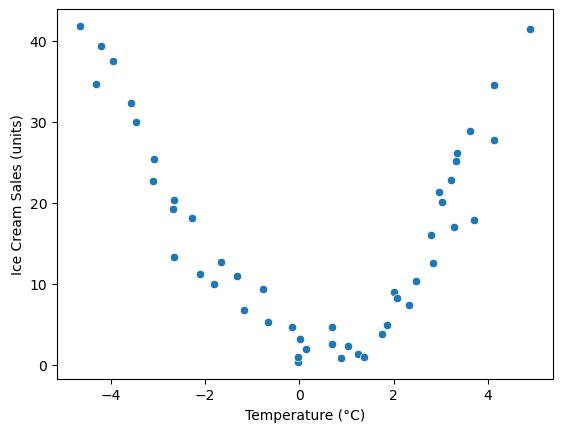

In [58]:
sns.scatterplot(data=df1,x="Temperature (°C)",y="Ice Cream Sales (units)")

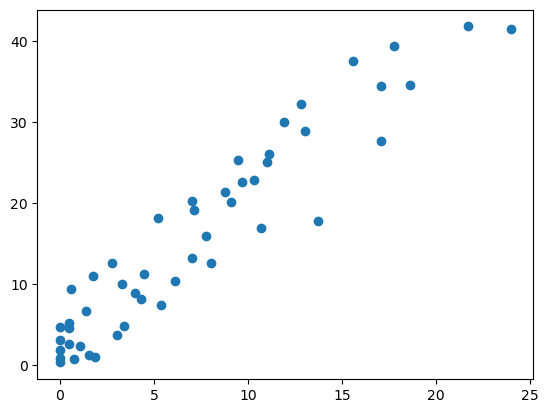

In [59]:
plt.scatter(df1['Temperature (°C)']*df1['Temperature (°C)'],df1["Ice Cream Sales (units)"])